In [67]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import utils



**Fuente: Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales**

| **Variable**           | **Definition**                                                                 |
|------------------------|--------------------------------------------------------------------------------|
| Pregnancies            | Número de embarazos del paciente (numérico)                                   |
| Glucose   |Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico |
|BloodPressure |Presión arterial diastólica (medida en mm Hg) (numérico) |
|SkinThickness | Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico) |
|Insulin |Insulina sérica de 2 horas (medida en mu U/ml) (numérico) |
|BMI| Índice de masa corporal (numérico) |
|DiabetesPedigreeFunction | Función de pedigrí de diabetes (numérico) | 
|Age | Edad del paciente (numérico) |
|Outcome |Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico) |

In [68]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
total_data = pd.read_csv(url)

Informacion general del Dataset:

In [69]:
total_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [70]:
total_data.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Revisar nulos y duplicados 

In [86]:
total_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [87]:
total_data.duplicated().sum()


np.int64(0)

In [88]:
total_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


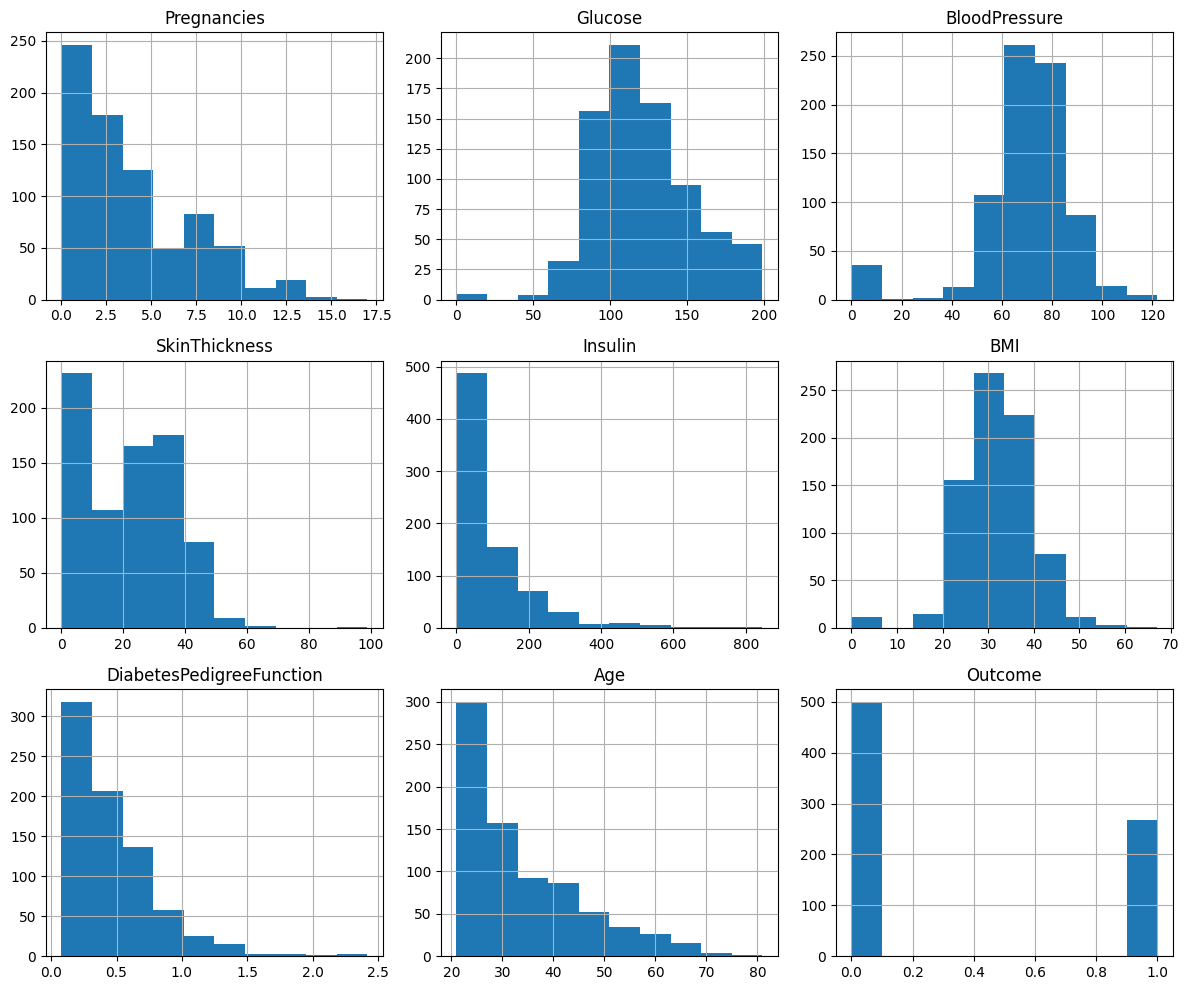

In [89]:
num_cols = total_data.select_dtypes(include='number')

num_cols.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [90]:
cat_cols = total_data.select_dtypes(include='object').columns
print(cat_cols)

Index([], dtype='object')


Conclusion:

Variables numéricas:
Cada columna representa una característica clínica o demográfica de los pacientes, como número de embarazos, nivel de glucosa, presión arterial, grosor de piel, insulina, índice de masa corporal (BMI), función de pedigrí de diabetes y edad.
Estas variables ayudan a entender el perfil de salud de cada paciente.

Variable objetivo (Outcome):
Es binaria:

0 significa que el paciente no tiene diabetes.
1 significa que el paciente tiene diabetes.
El objetivo del análisis es predecir este resultado a partir de las otras variables.
No hay valores nulos:
Todos los registros están completos, lo que facilita el análisis y evita problemas de calidad de datos.

No hay columnas categóricas tipo 'object':
Todas las variables son numéricas.

Duplicados:
El número de filas duplicadas es muy bajo o nulo, lo que indica que los datos fueron bien recopilados y no hay registros repetidos.

Distribución de variables:
Al visualizar los histogramas, puedes ver cómo se distribuyen los valores de cada variable. Por ejemplo, si hay muchos pacientes con niveles altos de glucosa o si la mayoría tiene una edad similar.
Esto ayuda a identificar posibles valores extremos (outliers) y entender el rango de cada característica.

ANÁLISIS EXPLORATORIO DE DATOS

##### 0. Preparación de los datos

In [96]:
# Definir la variable objetivo
target = "Outcome"

In [97]:
# Mover la variable objetivo al final (opcional pero útil para visualización)
df = df[[col for col in df.columns if col != target] + [target]]

##### 1. Análisis multivariable

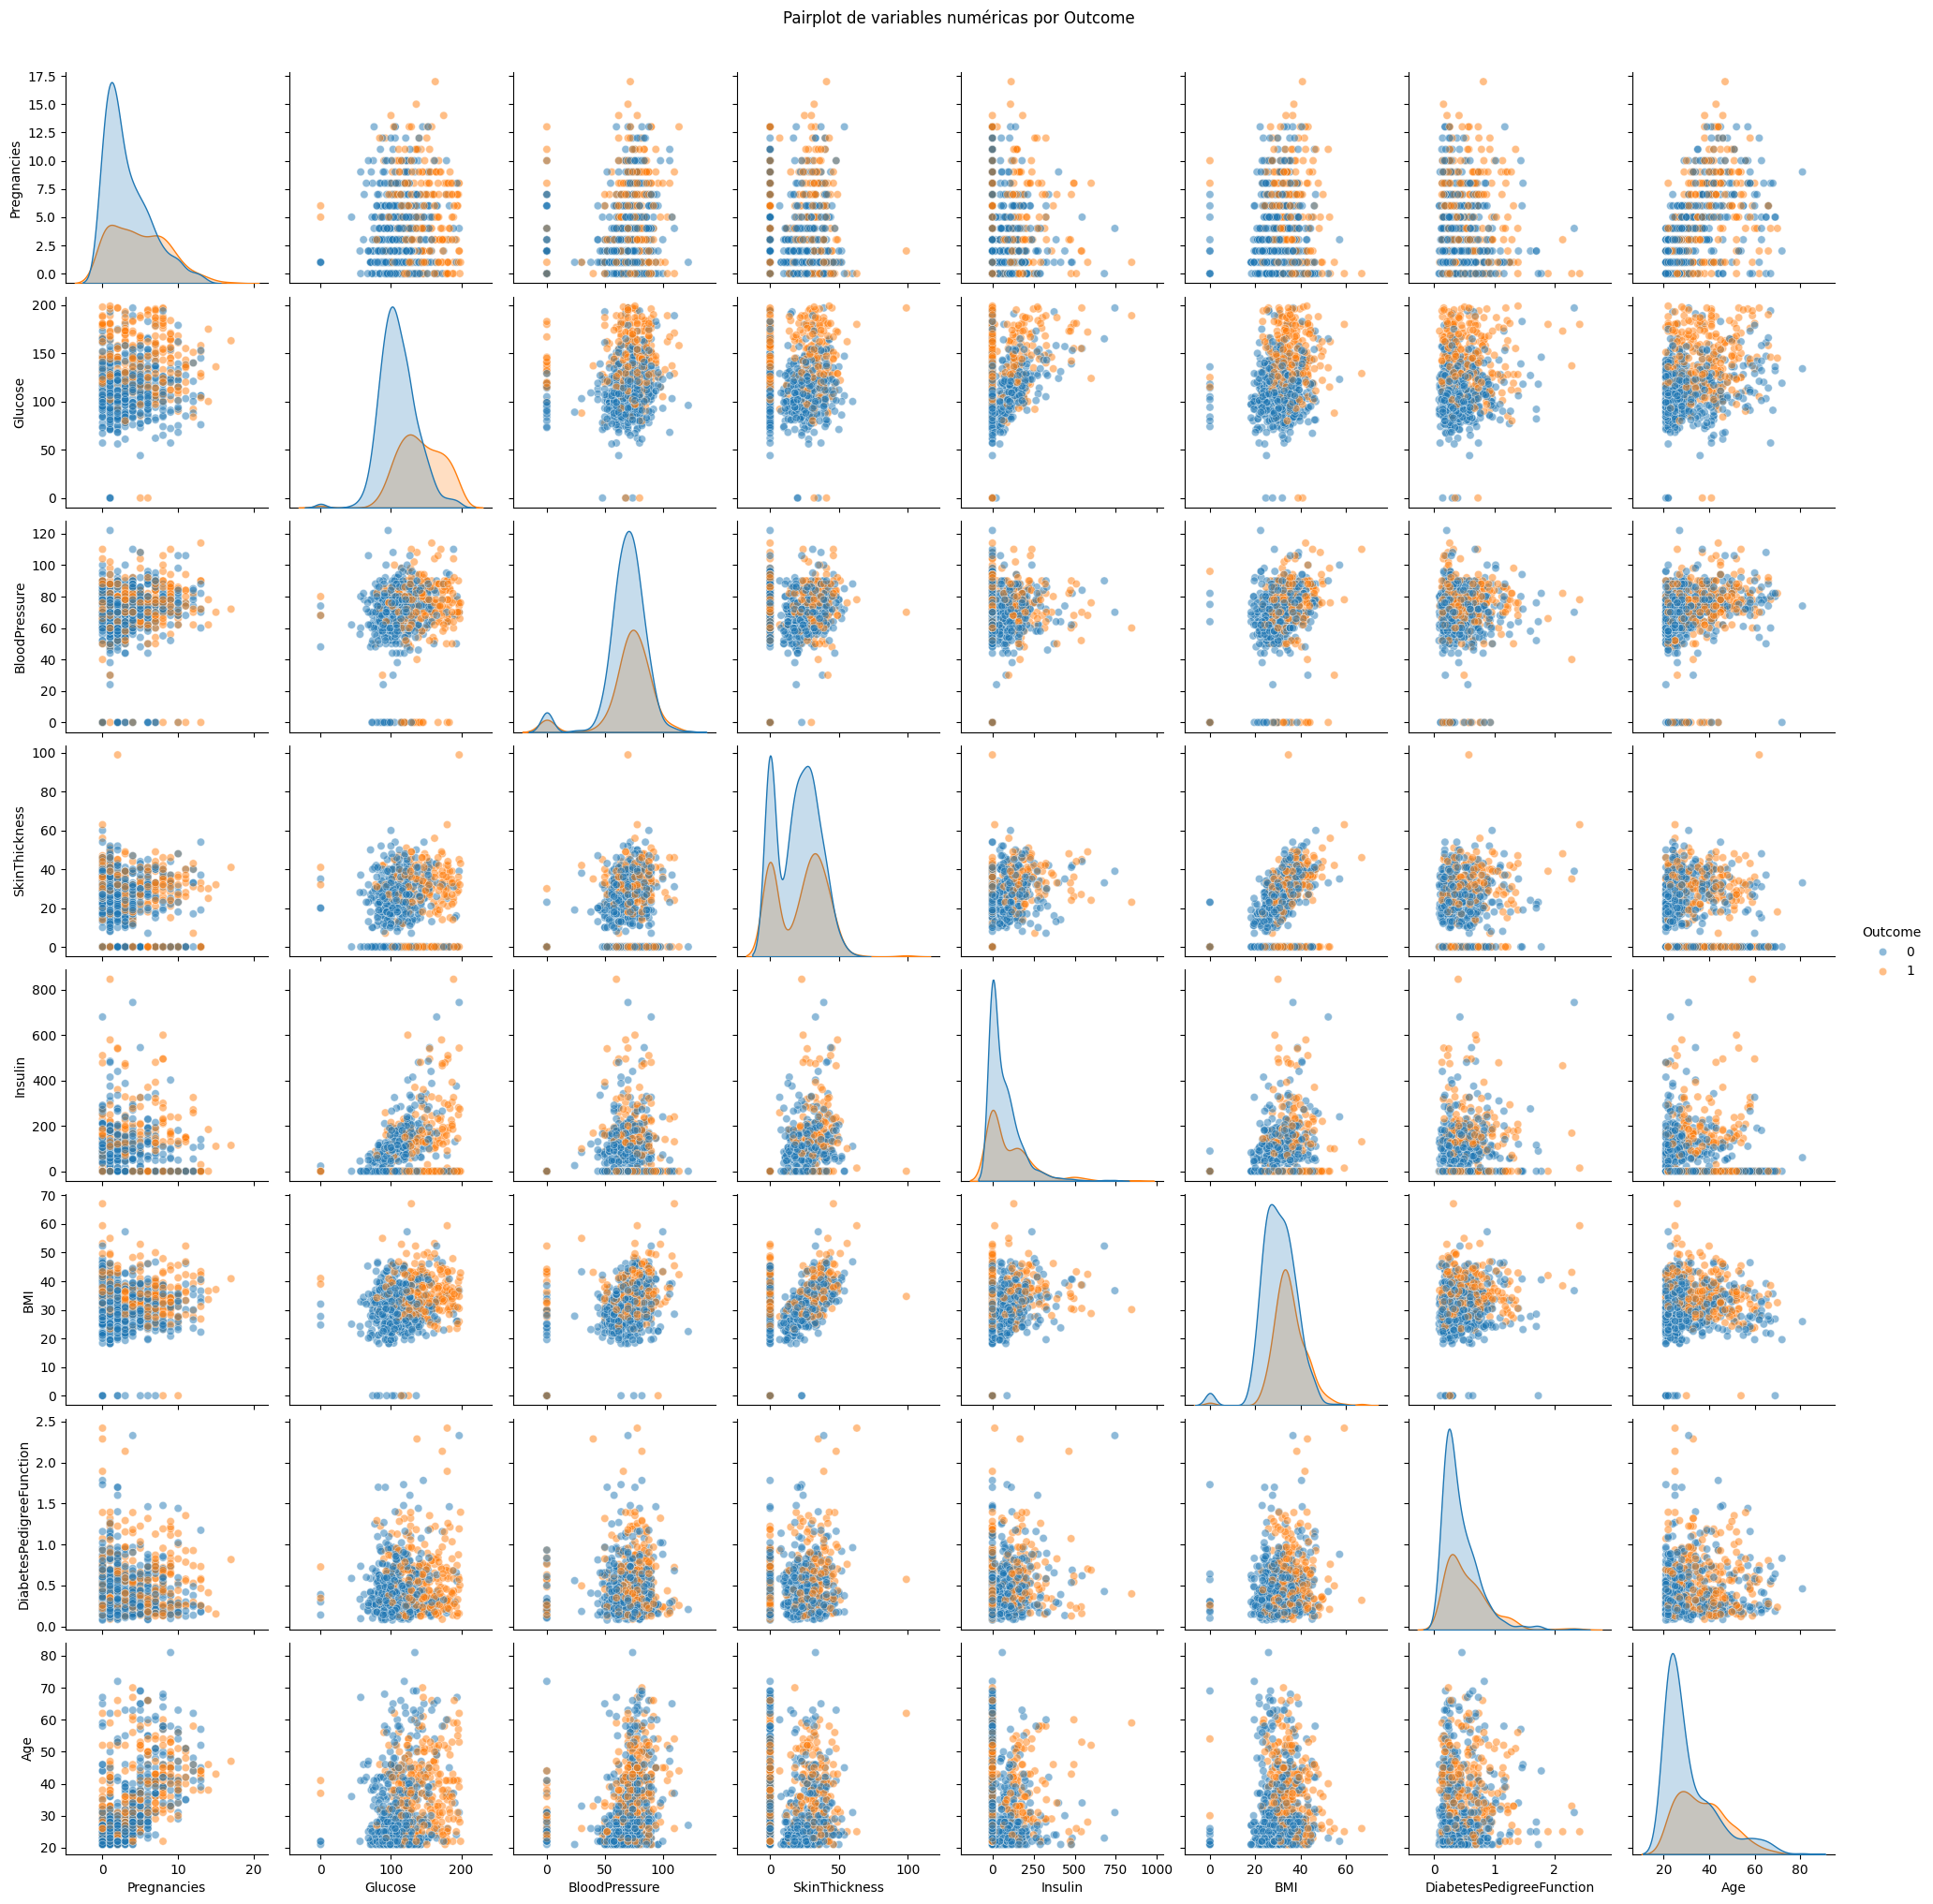

In [ ]:
# Correlaciones entre variables numéricas y target

sns.pairplot(df, hue=target, plot_kws={"alpha":0.5})
plt.suptitle("Pairplot de variables numéricas por Outcome", y=1.02)
plt.show()

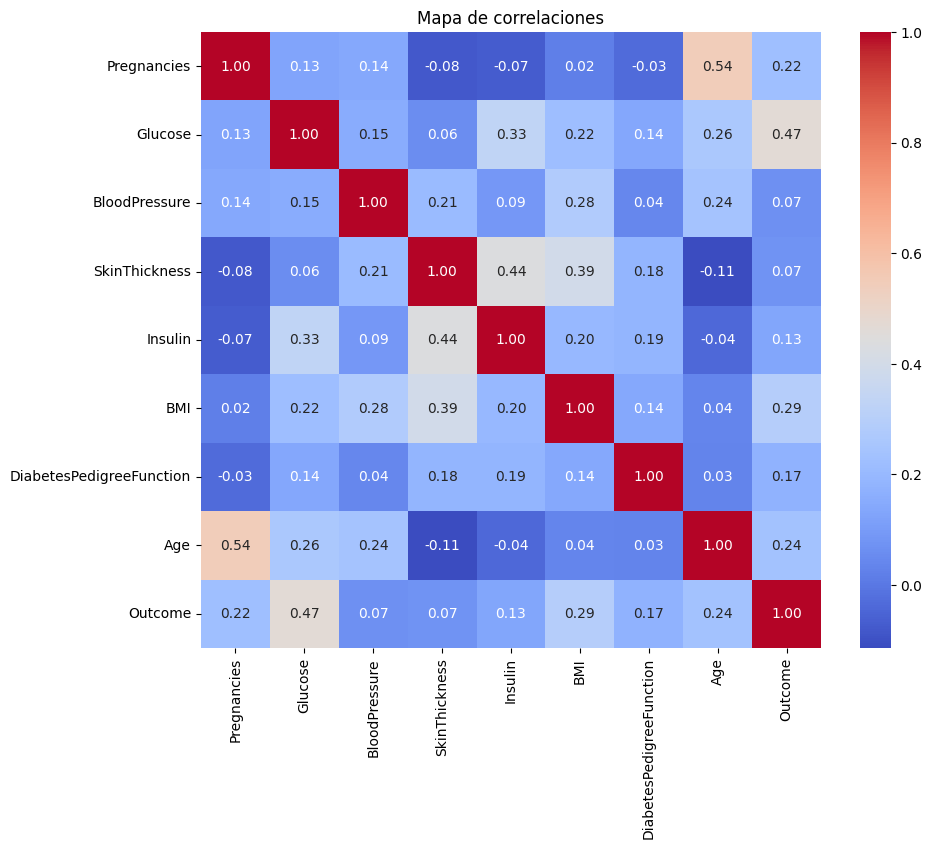

In [ ]:
# Mapa de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlaciones")
plt.show()

##### 2. Ingeniería de Características

In [100]:
# 2.1 Reemplazo de valores extremos (outliers comunes en este dataset: ceros en columnas que no deberían tenerlos)

# Crear copia
filtered_df = df.copy()

# Columnas con valores 0 sospechosos
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Reemplazar ceros por NaN
filtered_df[cols_with_zeros] = filtered_df[cols_with_zeros].replace(0, np.nan)

# Mostrar valores nulos por columna
filtered_df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [101]:
# 2.2 Rellenar con la media
clean_df = filtered_df.copy()
clean_df = clean_df.fillna(clean_df.mean())

##### 3. Guardar el dataset limpio



In [102]:
clean_df.to_csv("clean_diabetes.csv", index=False)

##### 4. División y escalado de datos

In [ ]:
variables = [x for x in df.columns if x != target]
X = clean_df[variables]
y = clean_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_norm = pd.DataFrame(scaler.fit_transform(X_train), columns=variables, index=X_train.index)
X_test_norm = pd.DataFrame(scaler.transform(X_test), columns=variables, index=X_test.index)
